In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform, swap
from scipy.ndimage import gaussian_filter
import pandas as pd

import ham_data as hd

### Get fidelity for input params

In [2]:
truc_full = 200

# truc1, truc_tot, charge_pick = 300, 1000, False
# folder = f'../../data/3ncut_two_zeropi/truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
# eval_tot = 2*np.pi* pd.read_csv(folder+ 'eval_tot.txt').to_numpy().flatten()
# n_theta0_dress = 2*np.pi* np.load(folder+'n_theta0_dress.npy')
# n_theta1_dress = 2*np.pi* np.load(folder+'n_theta1_dress.npy')
# hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()

folder_load = '../../data/_truc_3000'
[hspace_full, eket_tot, eval_tot, n_theta0_dress, n_theta1_dress, hspace_0, 
    hspace_1, logi_state] = hd.load_two_qubit_data(folder_load, return_full=False)    

truc_list = np.arange(truc_full)
hspace_full = hspace_full[:truc_full]
eval_tot = eval_tot[:truc_full]
n_theta0_dress = ut.truncate_2(n_theta0_dress, truc_list)
n_theta1_dress = ut.truncate_2(n_theta1_dress, truc_list)

workers, popsize = 100, 10
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.0)]

mid_state = '8-2'
logi_state = ['0-0', '0-2', '2-0', '2-2']
idx_0 = hspace_full.index('0-2')
idx_1 = hspace_full.index('2-2')
idx_2 = hspace_full.index(mid_state)
W_0_2 = eval_tot[idx_2] - eval_tot[idx_0]
W_1_2 = eval_tot[idx_2] - eval_tot[idx_1]

H0_full = qt.Qobj(np.diag(eval_tot))
logi_idx_full = [hspace_full.index(i) for i in logi_state]
state_full = [qt.basis(truc_full, i) for i in range(truc_full)]
H_drive_full = [ H0_full,   [n_theta0_dress, ut.drive_gauss_A],
                            [n_theta0_dress, ut.drive_gauss_B]  ]

c_op_list = []
num_cpus = 200

n02 = n_theta0_dress[idx_0, idx_2]
n12 = n_theta0_dress[idx_1, idx_2]
print(abs(n02), abs(n12))

max_step_ideal, max_step_noisy = 1e-3, 1e-3 # Set max_step to 0 for parallel execution
option_ideal, option_noisy = ut.get_qutip_options(max_step_ideal, max_step_noisy) 

0.2342735610128471 0.35866449445502113


In [6]:
print(eval_tot[:10])

[-83.83378269 -68.69262676 -67.52123553 -62.40017255 -62.40836136
 -62.19822546 -62.19422189 -54.3131255  -52.72462905 -51.8039306 ]


In [7]:
print(hspace_full[:10])

['0-0', '0-1', '1-0', '0-3', '0-2', '2-0', '3-0', '0-4', '4-0', '1-1']


In [8]:
logi_idx_full

[0, 4, 5, 21]

tg=200.003470, amp=0.0192, 0.0125, detune=-0.0050


2it [00:18,  9.44s/it]
2it [00:18,  9.32s/it]


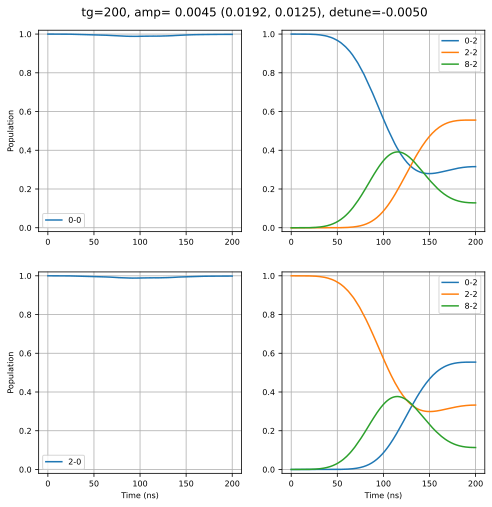

In [8]:
amp = 4.5e-3
detune = -0.005
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [2.0000347e+02,  2.1300000e-02,  1.3900000e-02, -5.0000000e-03,
  -5.0000000e-03]
# [339.990001, 0.107764, 0.067376, -0.071406, -0.035531]
# [200.00347, amp/abs(n02), amp/abs(n12), detune, detune]
print(f"tg={tg:.6f}, amp={amp/abs(n02):.4f}, {amp/abs(n12):.4f}, detune={detune:.4f}")
# [200.001513, 0.029121, 0.018721, -0.005572, -0.005265]
# [249.992868,0.022922,0.014688,-0.003423,-0.003252]
# 
arg_optimize = [tg, drive_amp_A, drive_amp_B, detune_A, detune_B]
pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': W_0_2 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': W_1_2 + 2*np.pi*detune_B,
            'gate_time': tg }
tlist = np.linspace(0, tg, num=10*int(tg))  # total time
logi_state_one = [0,2]

# Population in select
result = {}
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_drive_full,
            qt.basis(truc_full, hspace_full.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_full],
            args=pulse_args,
            options=option_ideal, 
            # options=qt.Options(store_states=True, num_cpus=num_cpus), 
            )
        
fig, ax = plt.subplots(figsize=(8,8), nrows=2, ncols=2)
fig.suptitle(f"tg={tg:.0f}, amp= {amp:.4f} ({amp/abs(n02):.4f}, {amp/abs(n12):.4f}), detune={detune:.4f}", fontsize=12, y=0.92)
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in enumerate(logi_state_one):
        for kdx, res in zip(hspace_full, result[idx,jdx].expect):
            y_pop = gaussian_filter( np.array(res).flatten(), 3)
            if np.max(y_pop) > 0.01:
                ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        ax[idx][jdx].legend()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
    # handles, labels = ax[idx][jdx].get_legend_handles_labels()
    # fig.legend(handles,labels, ncol=10,
    #     loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)        
    
fig.savefig('cnot_population.png', dpi=50, bbox_inches='tight')    

In [ ]:
arg_full = [H_drive_full, W_0_2, W_1_2, num_cpus, c_op_list, logi_idx_full, 
     mid_state, option_ideal, option_noisy]
# print("arg_optimize =", arg_optimize)
# print("arg_full =", arg_full)   
f_full = ut.cnot_fidelity_log_noise(arg_optimize, *arg_full)
print(f' f_full (dim={truc_full}) = ', f_full)
print('fidelity real = ', 1-10**f_full)

arg_optimize = [200.00347, 0.0213, 0.0139, -0.005, -0.005]
arg_full = [[Quantum object: dims = [[200], [200]], shape = (200, 200), type = oper, isherm = True
Qobj data =
[[-83.83378269   0.           0.         ...   0.           0.
    0.        ]
 [  0.         -68.69262676   0.         ...   0.           0.
    0.        ]
 [  0.           0.         -67.52123553 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ...   4.69472455   0.
    0.        ]
 [  0.           0.           0.         ...   0.           4.78825358
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    4.93431904]], [Quantum object: dims = [[200], [200]], shape = (200, 200), type = oper, isherm = True
Qobj data =
[[-5.14745753e-15+1.65090337e-31j  2.72445902e+00+4.76369115e-13j
  -8.05171277e+00-5.06150628e-15j ... -7.56564058e-05+8.02134244e-16j
   1.43616763e-15+1.30468647e-15j -7.01703328e-16-2.06773328e-15j]
 [ 2.72445902e+00-4.76369115e-13j -1.36

In [ ]:
data = hspace_full
dim = 10
for i in range(0, len(data), dim):  # Step size of 10
    if i%50==0:
        print('')
    print(", ".join(f"'{x}'" for x in data[i:i + dim]), ',')


'0-0', '0-1', '1-0', '0-3', '0-2', '2-0', '3-0', '0-4', '4-0', '1-1' ,
'0-5', '0-6', '2-1', '3-1', '5-0', '6-0', '1-2', '1-3', '0-7', '7-0' ,
'0-8', '2-2', '3-3', '3-2', '2-3', '1-4', '8-0', '4-1', '0-9', '0-10' ,
'0-11', '3-4', '2-4', '9-0', '10-0', '1-5', '1-6', '5-1', '6-1', '4-3' ,
'4-2', '11-0', '1-7', '0-12', '7-1', '2-5', '3-5', '2-6', '3-6', '1-8' ,

'12-0', '5-2', '6-3', '5-3', '6-2', '0-13', '0-14', '0-15', '0-16', '0-17' ,
'8-1', '2-7', '3-7', '4-4', '13-0', '14-0', '7-2', '7-3', '15-0', '16-0' ,
'17-0', '2-8', '3-8', '1-9', '1-10', '1-11', '9-1', '6-4', '8-2', '8-3' ,
'5-4', '10-1', '4-5', '4-6', '11-1', '0-18', '4-7', '3-9', '2-9', '0-19' ,
'7-4', '3-10', '2-10', '1-12', '3-11', '2-11', '0-20', '0-22', '18-0', '0-21' ,

'0-23', '9-2', '9-3', '10-2', '10-3', '12-1', '5-5', '5-6', '6-5', '6-6' ,
'0-24', '19-0', '4-8', '11-3', '11-2', '1-13', '1-14', '20-0', '21-0', '8-4' ,
'1-16', '22-0', '1-15', '5-7', '6-7', '23-0', '1-17', '2-12', '3-12', '13-1' ,
'7-5', '14-1', '7-6', '

In [ ]:
sorted_idx = np.argsort(eval_tot)
a = sorted_idx

In [ ]:
idx = np.where(a[:-1] > a[1:])[0]
print("违反升序的位置：", idx)
print("总数量：", len(idx))

bad_pairs = np.vstack([a[idx], a[idx+1]]).T
print(bad_pairs)

违反升序的位置： [  3  23  31  39  52  53  61  87  91  94 113 137 148 153 154 155 156 158
 166 183 191]
总数量： 21
[[  4   3]
 [ 24  22]
 [ 32  31]
 [ 40  39]
 [ 54  52]
 [ 52  50]
 [ 62  60]
 [ 88  87]
 [ 92  91]
 [ 95  94]
 [114 113]
 [138 137]
 [149 148]
 [157 156]
 [156 154]
 [154 152]
 [152 151]
 [159 158]
 [167 165]
 [184 183]
 [192 191]]


# Old

In [5]:
pop = np.array(result[0,0].expect)
print(np.shape(pop))
pop_integral = pop.sum(axis=1)
print(np.shape(pop_integral))

ut.top_population(np.array(result[0,0].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[0,1].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[1,0].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[1,1].expect).sum(axis=1), hspace_full)

(100, 160)
(100,)

Top 10 values: [0.9805, 0.0104, 0.0044, 0.003, 0.0013, 0.0003, 0.0001, 0.0001, 0.0, 0.0]
State of large population: ['0-0' '8-0' '2-0' '1-0' '1-4' '0-1' '8-1' '0-4' '4-0' '12-0']

Top 10 values: [0.674, 0.2434, 0.0786, 0.0022, 0.001, 0.0004, 0.0002, 0.0001, 0.0, 0.0]
State of large population: ['0-2' '8-2' '2-2' '1-2' '1-5' '4-2' '5-2' '0-5' '4-5' '2-5']

Top 10 values: [0.9813, 0.0101, 0.0043, 0.0025, 0.001, 0.0005, 0.0001, 0.0001, 0.0001, 0.0001]
State of large population: ['2-0' '8-0' '0-0' '5-0' '1-4' '2-1' '15-0' '8-1' '0-4' '9-1']

Top 10 values: [0.6879, 0.2293, 0.0791, 0.002, 0.0009, 0.0004, 0.0003, 0.0001, 0.0, 0.0]
State of large population: ['2-2' '8-2' '0-2' '5-2' '1-5' '4-2' '1-2' '2-5' '4-5' '0-5']


In [ ]:
=

In [7]:
idx_00 = [hspace_full.index(i) for i in ['0-0', '2-0', '8-0']]
idx_02 = [hspace_full.index(i) for i in ['0-2', '2-2', '8-2']]
idx_20 = [hspace_full.index(i) for i in ['0-0', '2-0', '8-0']]
idx_22 = [hspace_full.index(i) for i in ['0-2', '2-2', '8-2']]

col_00 = ['tg'] + ['0-0', '2-0', '8-0'] + ['other']
col_02 = ['tg'] + ['0-2', '2-2', '8-2'] + ['other']
col_20 = ['tg'] + ['0-0', '2-0', '8-0'] + ['other']
col_22 = ['tg'] + ['0-2', '2-2', '8-2'] + ['other']

idx_vec = [idx_00, idx_02, idx_20, idx_22]
col_vec = [col_00, col_02, col_20, col_22]

In [9]:
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        state_interest = idx_vec[2*idx+jdx]
        column = col_vec[2*idx+jdx]
        pop = np.array(result[idx,jdx].expect)

        pop_interest = pop[state_interest, :]
        pop_other = np.delete(pop, state_interest, axis=0).sum(axis=0)
        pop_save = np.vstack((tlist,pop_interest, pop_other)).T

        df = pd.DataFrame(pop_save, columns=column)
        df.to_csv(f'data/data_fig/cnot_population_tg={int(tg)}_{state_i}{state_j}_3ncut.txt', sep=',', index=False, header=True)

2it [00:00, 226.49it/s]
2it [00:00, 285.89it/s]


2it [00:00, 61.47it/s]
2it [00:00, 64.33it/s]


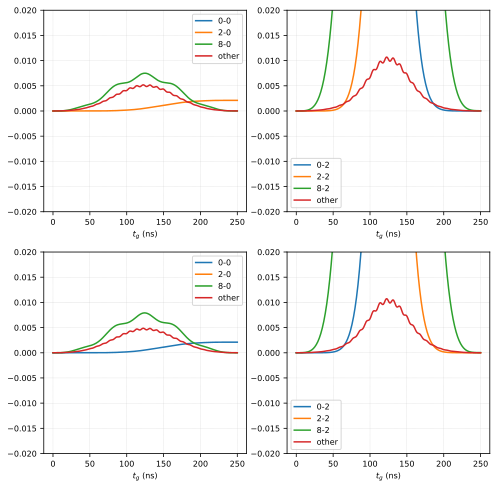

: 

In [ ]:
x_size, y_size = 8, 8
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(x_size, y_size))
for i, state_i in enumerate(logi_state_one):
    for j, state_j in tqdm(enumerate(logi_state_one)):
        pop_ij = pd.read_csv(f'data/data_fig/cnot_population_{state_i}{state_j}_3ncut.txt').to_numpy()
        for k in np.arange(1, pop_ij.shape[1]):
            ax[i][j].plot( pop_ij[:,0], gaussian_filter( pop_ij[:,k], 3), '-', label=col_vec[2*i+j][k])        
        # ax[i].set_xlim(-25, 25)
        # ax[i][j].set_ylim(-0.02, 0.02)
        ax[i][j].legend()
        ax[i][j].grid(linewidth=0.2, linestyle='--')
        ax[i][j].set_xlabel(r'$t_g$ (ns)')

In [33]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
def top_population(pop_integral, hspace_full, num=10):
    # Get the indices of the top 10 largest values
    top_indices = np.argsort(pop_integral)[-num:]  # Sort and take the last 10 indices
    
    top_values = pop_integral[top_indices] # Get the top 10 largest values
    
    sorted_order = np.argsort(top_values)[::-1] # Sorting in descending order (optional)
    top_indices = top_indices[sorted_order]
    top_values = top_values[sorted_order]
    print("\nTop 10 values:", np.round(top_values,8))

    state_top = (np.array(hspace_full)[top_indices.tolist()]).tolist()
    print("State of large population:", )
    for i in range(0, len(state_top), 10):  # Step size of 10
        print(", ".join(f"'{x}'" for x in state_top[i:i + 10]), ',')
    return None

In [ ]:
pop = np.array(result[0,0].expect)
print(np.shape(pop))
pop_integral = pop.sum(axis=1)
print(np.shape(pop_integral))
p_tot = ( np.array(result[0,0].expect).sum(axis=1) + np.array(result[0,1].expect).sum(axis=1) + 
np.array(result[1,0].expect).sum(axis=1) + np.array(result[1,1].expect).sum(axis=1) )

# top_population(np.array(result[0,0].expect).sum(axis=1), hspace_full, num=50)
# top_population(np.array(result[0,1].expect).sum(axis=1), hspace_full, num=50)
# top_population(np.array(result[1,0].expect).sum(axis=1), hspace_full, num=50)
top_population(p_tot, hspace_full, num=300)

(400, 200)
(400,)

Top 10 values: [1.98287896e+02 1.98272443e+02 1.71325114e+02 1.70412999e+02
 5.62037869e+01 2.20395441e+00 4.01751310e-01 3.29969730e-01
 3.29322280e-01 3.10778450e-01 3.06219680e-01 2.63581650e-01
 2.48692470e-01 2.38552740e-01 1.22739450e-01 1.15449390e-01
 9.50817500e-02 6.34355900e-02 6.11860800e-02 4.59243400e-02
 4.06464800e-02 3.60061100e-02 3.41932300e-02 2.39671800e-02
 1.88356000e-02 1.69182000e-02 1.59911300e-02 1.58799600e-02
 1.41804000e-02 1.30870200e-02 1.14554100e-02 1.07663600e-02
 9.56165000e-03 9.40418000e-03 8.97186000e-03 8.82988000e-03
 6.18649000e-03 5.02875000e-03 4.24361000e-03 3.99744000e-03
 3.71334000e-03 3.16240000e-03 2.81834000e-03 2.78955000e-03
 2.10649000e-03 1.95455000e-03 1.94987000e-03 1.73371000e-03
 1.71999000e-03 1.58427000e-03 1.52768000e-03 1.43241000e-03
 1.37563000e-03 1.36553000e-03 1.23501000e-03 1.16687000e-03
 1.14933000e-03 1.07955000e-03 9.55380000e-04 9.18630000e-04
 8.64650000e-04 8.31270000e-04 7.61770000e-04 7.285

: 

In [ ]:
# Fidelity in select
hspace_select = [
'0-0', '0-1', '1-0', '0-2', '2-0', '0-4', '4-0', '1-1', '0-5', '2-1' ,
'5-0', '1-2', '0-8', '2-2', '8-0', '1-4', '4-1', '2-4', '9-0', '1-5' ,
'5-1', '4-2', '0-12', '2-5', '1-8', '12-0', '5-2', '8-1', '4-4', '13-0' ,
'15-0', '2-8', '1-9', '9-1', '8-2', '5-4', '4-5', '0-18', '2-9', '0-21' ,
'18-0', '9-2', '12-1', '5-5', '0-24', '4-8', '1-13', '20-0', '8-4', '22-0' ,
'2-12', '13-1', '24-0', '0-25', '15-1', '5-8', '4-9', '12-2', '9-4', '8-5' ,
'25-0', '13-2', '26-0', '1-18', '15-2', '5-9', '4-12', '0-30', '18-1', '12-4' ,
'9-5', '1-21', '8-8', '20-1', '4-13', '22-1', '4-16', '30-0', '13-4', '5-12' ,
'15-4', '24-1', '33-0', '18-2', '34-0', '2-21', '8-9', '35-0', '1-25', '9-8' ,
'12-5', '37-0', '20-2', '5-16', '22-2', '13-5', '25-1', '26-1', '24-2', '15-5' ,
'2-25', '39-0', '8-12', '2-26', '9-9', '18-4', '28-1', '12-8', '41-0', '0-45' ,
'4-21', '13-8', '25-2', '20-4', '22-4', '4-24', '26-2', '5-18', '15-8', '30-1' ,
'9-12', '44-0', '12-9', '28-2', '45-0', '33-1', '18-5', '2-30', '46-0', '34-1' ,
'13-9', '9-13', '9-16', '20-5', '22-5', '50-0', '30-2', '25-4', '15-9', '8-18' ,
'24-5', '12-12', '33-2', '18-8', '34-2', '35-2', '13-12', '41-1', '37-2', '22-8' ,
'56-0', '25-5', '26-5', '30-4', '18-9', '39-2', '13-16', '59-0', '33-4', '28-5' ,
'41-2', '35-4', '20-9', '22-9', '25-8', '65-0', '26-8', '24-9', '30-5', '12-18' ,
'44-2', '33-5', '45-2', '34-5', '35-5', '46-2', '12-20', '69-0', '37-5', '26-9' ,
'50-2', '51-2', '39-5', '54-2', '41-5', '56-2', '58-2', '34-9', '18-20', '59-2' ,
'44-5', '45-5', '60-2', '41-8', '46-5', '64-2', '65-2', '33-12', '50-5', '51-5' ,
]
index_select = [hspace_full.index(i) for i in hspace_select]
H0_select = ut.truncate_2( H0_full, index_select)
len_select = len(hspace_select)
n_theta0_select = ut.truncate_2(n_theta0_dress, index_select)
logi_idx_select = [hspace_select.index(i) for i in logi_state]
state_select = [qt.basis(len_select, i) for i in range(len_select)]
H_drive_select = [ H0_select,   [n_theta0_select, ut.drive_gauss_A],
                                [n_theta0_select, ut.drive_gauss_B]  ]

arg_select = [H_drive_select, W_0_2, W_1_2, num_cpus, c_op_list, logi_idx_select]
f_select = ut.cnot_fidelity_log_tg(arg_optimize, *arg_select)
print(f' f_full (dim={len_select}) = ', f_select)
print('fidelity real = ', 1-10**f_select)


# Population in select
result = {}
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_drive_select,
            qt.basis(len_select, hspace_select.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_select],
            args=pulse_args,
            options=qt.Options(store_states=True, nsteps=1e4)  )

fig, ax = plt.subplots(figsize=(8,8), nrows=2, ncols=2)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in enumerate(logi_state_one):
        for kdx, res in zip(hspace_select, result[idx,jdx].expect):
            y_pop = gaussian_filter( np.array(res).flatten(), 3)
            # if np.max(y_pop) > 0.001:
            ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].legend()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')

    handles, labels = ax[idx][jdx].get_legend_handles_labels()
    fig.legend(handles,labels, ncol=5,
        loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)

 f_full (dim=200) =  -0.7118681015876595
fidelity real =  0.8058524571641797


In [ ]:
# # Fidelity in full
# arg_full = [H_drive_full, W_0_2, W_1_2, num_cpus, c_op_list, logi_idx_full]
# f_full = ut.cnot_fidelity_log_tg(arg_optimize, *arg_full)
# print(f' f_full (dim={truc_full}) = ', f_full)

# # Population in full
# result = {}
# for idx, state_i in enumerate(logi_state_one):
#     for jdx, state_j in tqdm(enumerate(logi_state_one)):
#         # This simulation is just for viewing the affect of the pulse
#         result[idx, jdx] = qt.mesolve(
#             H_drive_full,
#             qt.basis(truc_full, hspace_full.index( str(state_i) +'-'+str(state_j) )),
#             tlist,
#             e_ops=[state * state.dag() for state in state_full],
#             args=pulse_args,
#             options=qt.Options(store_states=True, nsteps=1e4)  )

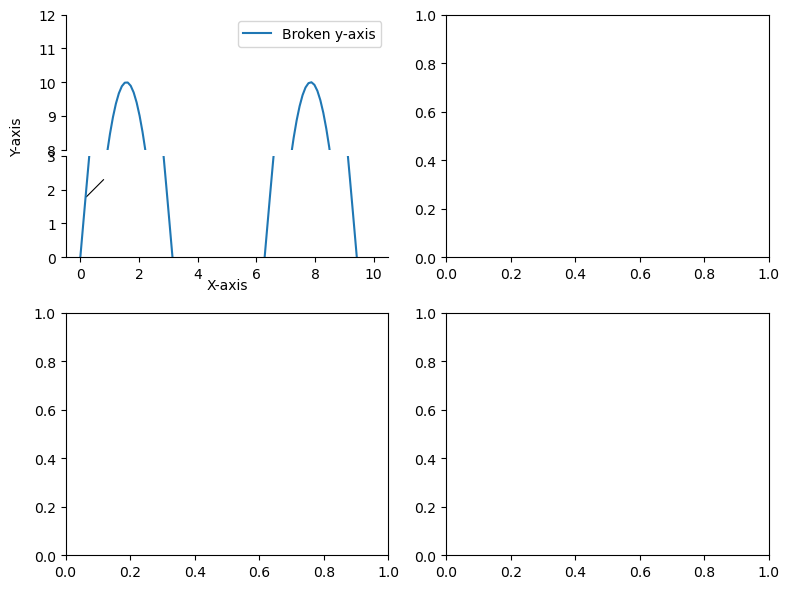

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from brokenaxes import brokenaxes

# Create a 2×2 figure
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Define the subplot where we want a broken y-axis (e.g., axes[0,0])
fig.delaxes(axes[0, 0])  # Remove the default subplot to replace with brokenaxes

# Create a broken y-axis in subplot (0,0)
bax = brokenaxes(ylims=((0, 3), (8, 12)),  # Define broken y-axis ranges
                 hspace=0.05,              # Space between the broken axes
                 subplot_spec=fig.add_gridspec(2, 2)[0, 0])  # Position in 2×2 grid

# Sample data
x = np.linspace(0, 10, 100)
y = np.sin(x) * 10

# Plot data on broken axes
bax.plot(x, y, label="Broken y-axis")

# Customize
bax.legend()
bax.set_xlabel("X-axis")
bax.set_ylabel("Y-axis")

# Show the figure
plt.tight_layout()
plt.show()


/tmp/ipykernel_1475680/2143967905.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


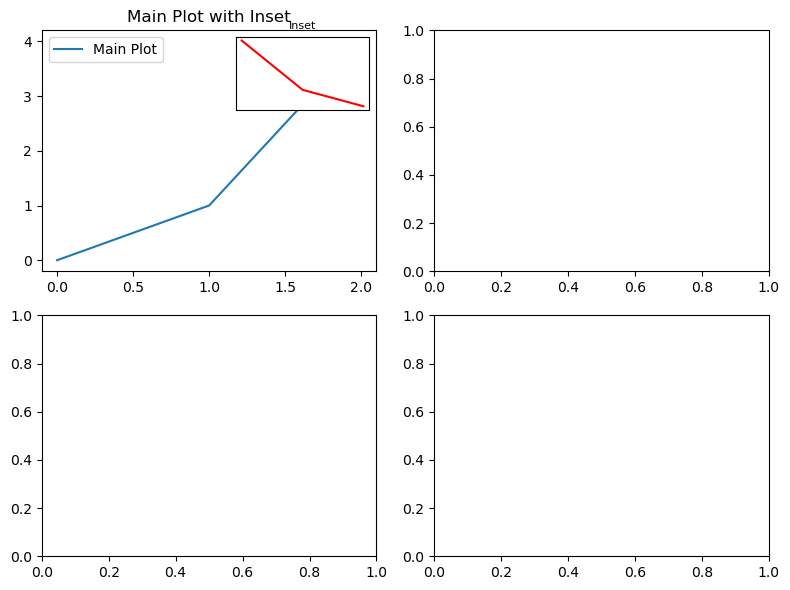

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create a 2×2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Select the subplot for the inset (Top-Left: axes[0,0])
ax_main = axes[0, 0]
ax_main.plot([0, 1, 2], [0, 1, 4], label="Main Plot")
ax_main.set_title("Main Plot with Inset")
ax_main.legend()

# Add inset inside axes[0,0]
ax_inset = inset_axes(ax_main, width="40%", height="30%", loc="upper right")  # width & height in %
ax_inset.plot([0, 1, 2], [4, 1, 0], 'r')  # Inset plot
ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.set_title("Inset", fontsize=8)

plt.tight_layout()
plt.show()
